# Pomocné nástroje pro prezentaci výsledků v textu bakalářské práce

In [8]:
import os
import json
import jsonlines
import subprocess
import matplotlib.pyplot as plt
import numpy as np
from coordinates import CoordinateConvertor


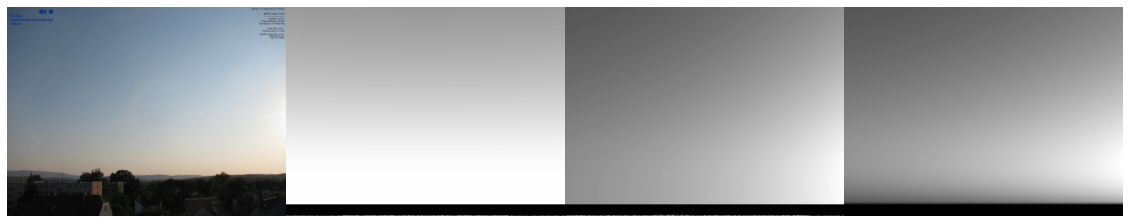

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

im1 = '../data/Jsmall/ceske_budejovice/20230531/1935.jpg'
im2 = 'perez-ind.png'
im3 = 'perez2.png'
im4 = 'prague2.png'

for i, img in enumerate([im1, im2, im3, im4]):
    axes[i].imshow(plt.imread(img), cmap='gray')
    axes[i].axis('off')


plt.subplots_adjust(wspace=0, hspace=0.0)
plt.show()

In [47]:
data = json.load(open('../data/p4p.json'))


In [43]:
for location in data['locations']:
    print(data['locations'][location]['filenames'])
    locfolder = '../data/p4p-images/'+location
    os.mkdir(locfolder)
    for i, image in enumerate(data['locations'][location]['filenames']):
        command = f'scp bc:{image} {locfolder}/{i}.jpg'
        subprocess.run(command, shell=True)

['/projects/SkyGAN/webcams/chmi.cz/sky_webcams/belotin/20210326/0605.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/belotin/20210326/0630.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/belotin/20210326/0700.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/belotin/20210822/0645.jpg']
['/projects/SkyGAN/webcams/chmi.cz/sky_webcams/dukovany/20220118/0825.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/dukovany/20221006/0805.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/dukovany/20221006/0855.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/dukovany/20230120/0910.jpg']
['/projects/SkyGAN/webcams/chmi.cz/sky_webcams/brno/20210625/0630.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/brno/20210625/0530.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/brno/20210625/0730.jpg', '/projects/SkyGAN/webcams/chmi.cz/sky_webcams/brno/20210625/0700.jpg']
['/projects/SkyGAN/webcams/chmi.cz/sky_webcams/ceske_budejovice/20210405/1630.jpg', '/projects/SkyGAN/webcams/chmi.cz

# Dataset Preview

brno
ceske_budejovice
dukovany
holesov
nedvezi
olomouc
polom
pribyslav
primda
temelin


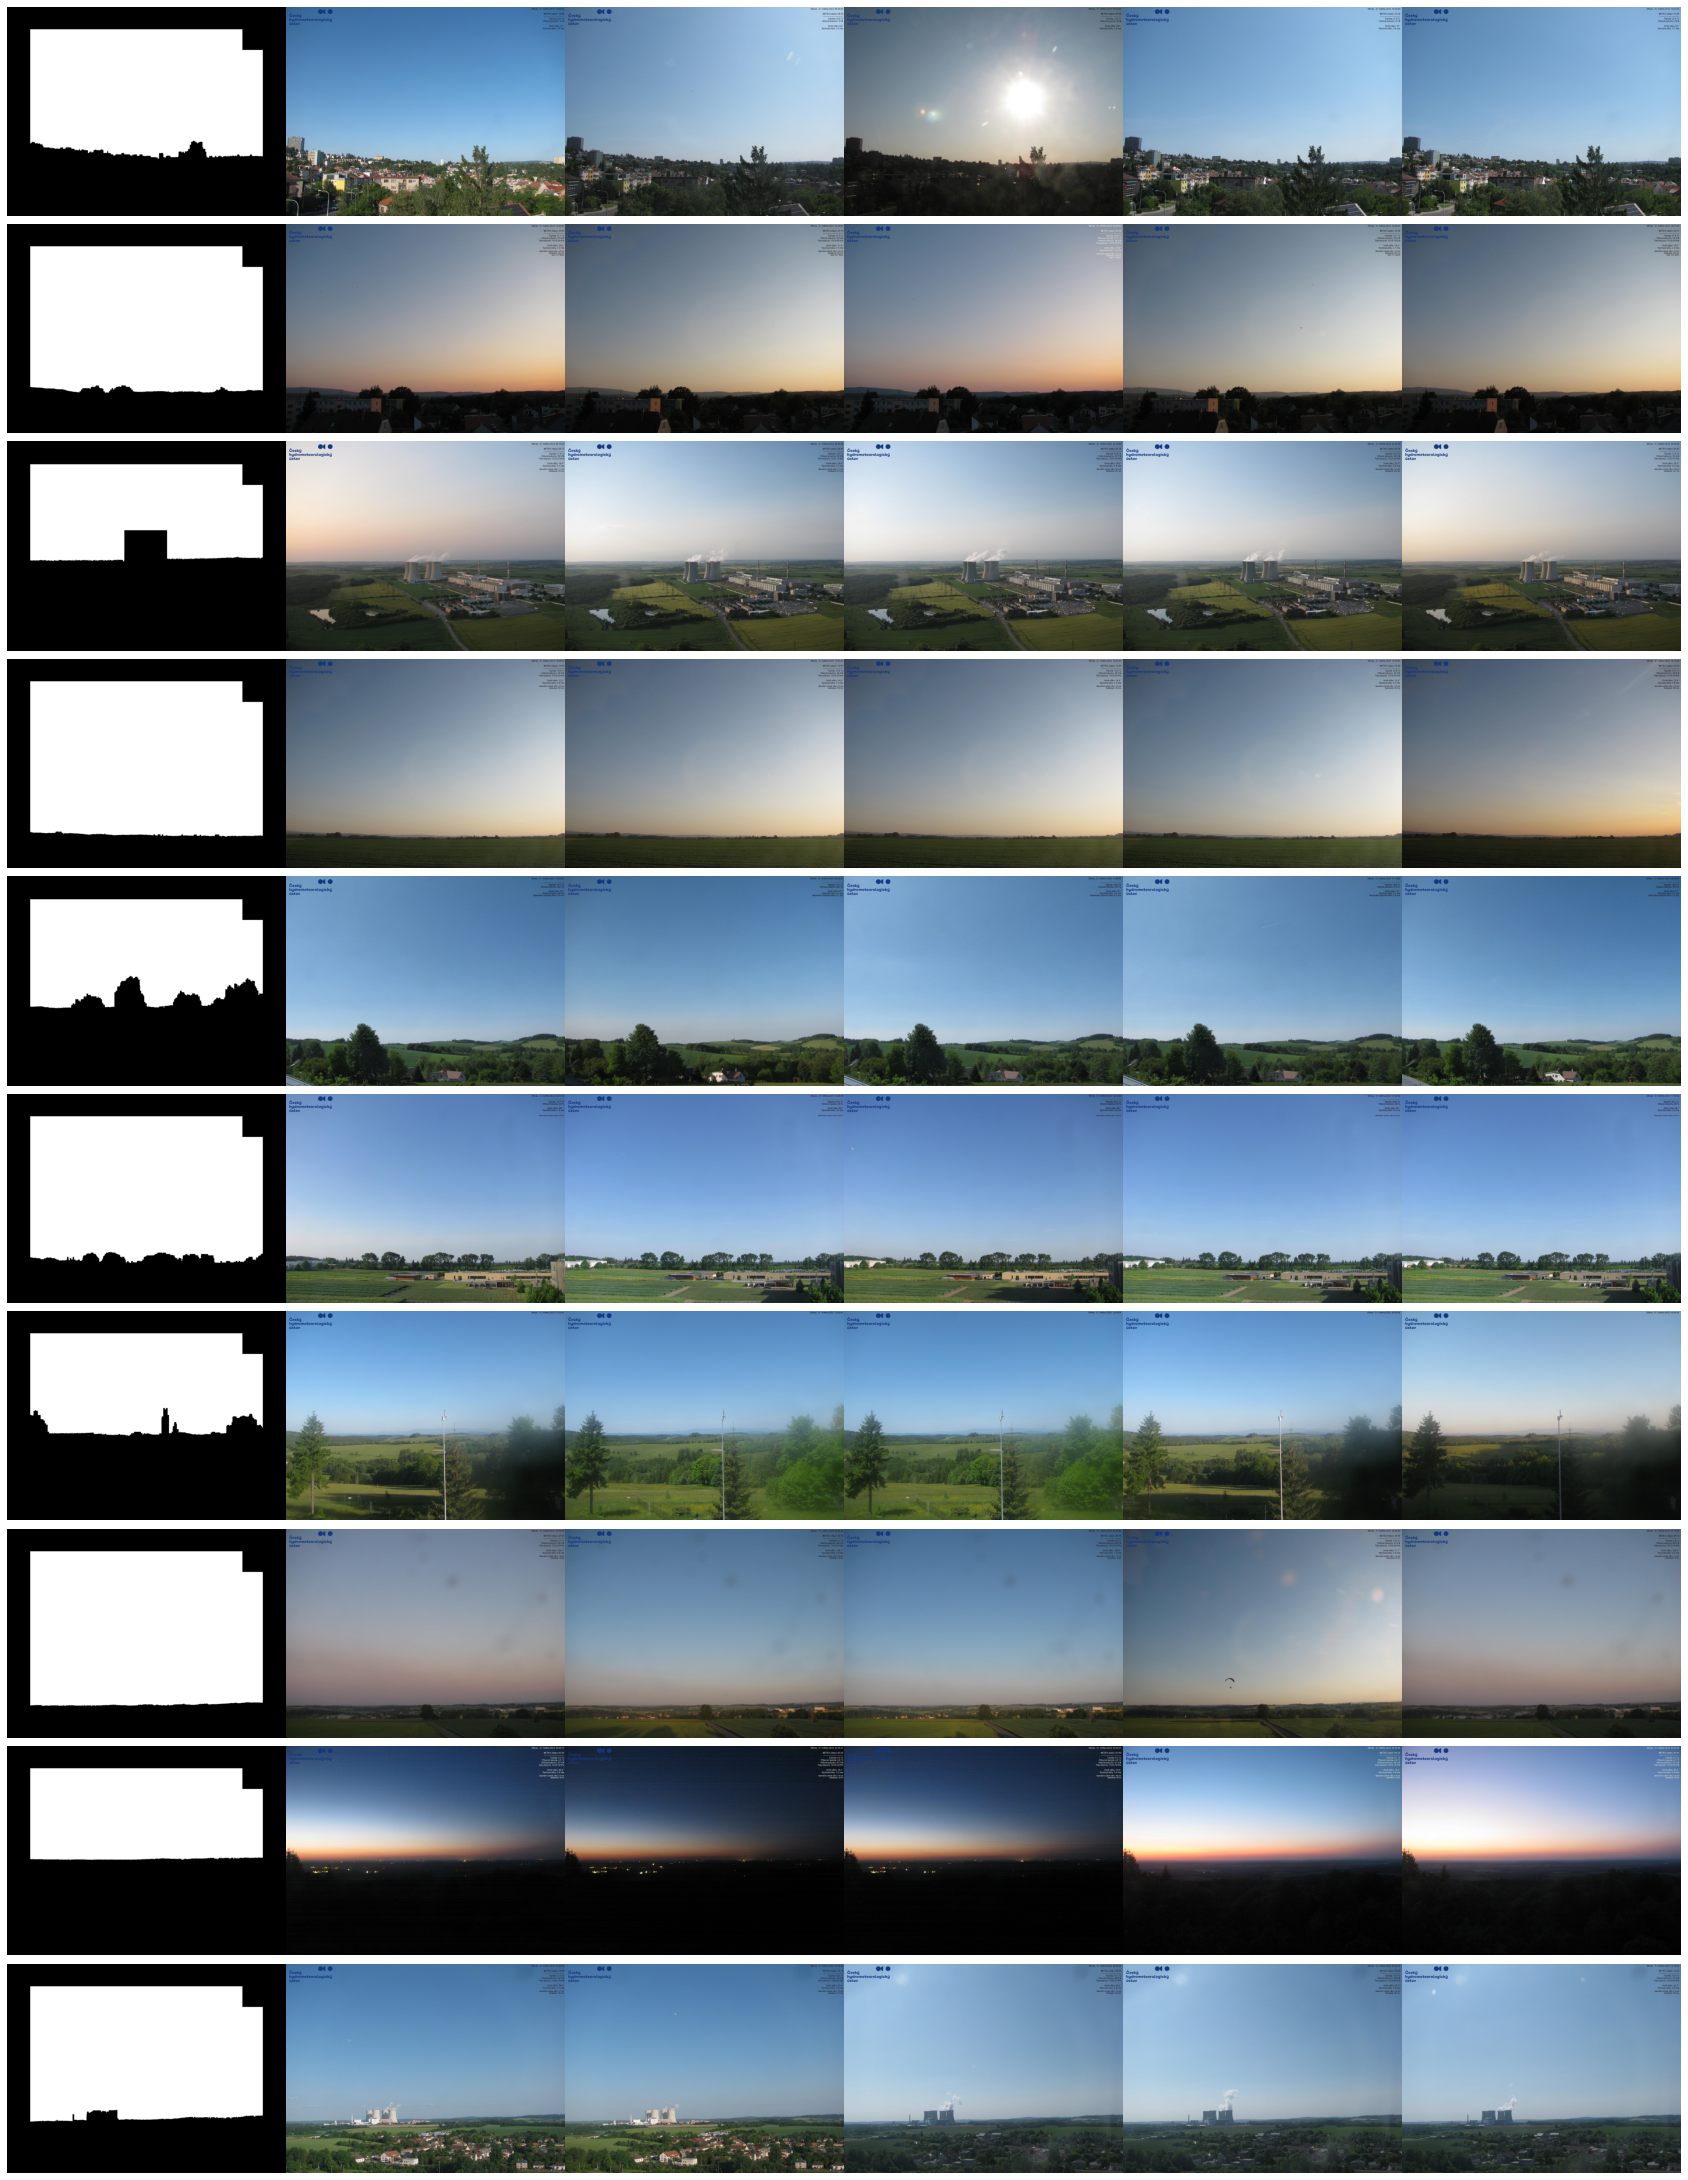

In [72]:
fig, axes = plt.subplots(10, 6, figsize=(30, 40))


for i, location in enumerate(os.listdir('../data/Ismall/')):
    print(location)
    axes[i, 0].set_ylabel(location, rotation='vertical', fontsize=12)
    axes[i, 0].axis('off')

    axes[i, 0].imshow(plt.imread(f'../data/masks/{location}.jpg'), cmap='gray')
    files = np.array(os.listdir(f'../data/Jsmall/{location}/20230531/'))
    for j, file in enumerate(files[np.random.choice(len(files), 5)]):
       axes[i, j+1].imshow(plt.imread(f'../data/Jsmall/{location}/20230531/{file}'))
       axes[i, j+1].axis('off')



plt.subplots_adjust(wspace=0, hspace=0.0)
plt.show()

In [9]:
def angle_diff(x, y):
    a = (x - y) % 360
    b = (y - x) % 360
    return np.where(a < b, -a, b)

# Diffs

In [10]:
def results(file_path_large, file_path_small):
    truth = np.array([45, 270, 135, 270, 180, 180, 270, 225, 90, 135])
    names = ['Brno & 45\\textdegree', 'Č. Budějovice & 270\\textdegree', 'Dukovany & 135\\textdegree', 'Holešov & 270\\textdegree', 'Nedvězí & 180\\textdegree',
                'Olomouc & 180\\textdegree', 'Polom & 270\\textdegree', 'Přibyslav & 225\\textdegree', 'Přimda & 90\\textdegree', 'Temelín & 135\\textdegree']
    W, H = 720, 540
    #file_path_large = 'chmu-prague-log.txt'
    #file_path_small = 'chmu-prague-clean-log.txt'
    convertor = CoordinateConvertor(W, H)

    results_large, results_small = [], []

    with jsonlines.open(file_path_large) as reader1, jsonlines.open(file_path_small) as reader2:
        for document_large, document_small, i in zip(reader1, reader2, range(10)):

            try:
                fov1 = np.rad2deg(convertor.f_to_fov(document_large["f"]))%360
                #print(f'{names[i]:<30}  & {document_large["phi"]%360:.2f}\\textdegree  \t & {document_large["theta"]:.2f}\\textdegree  \t & {fov1:.2f}\\textdegree', end='')  
                results_large.append([document_large["phi"]%360, document_large["theta"], fov1])
            except:
                #print(f"{names[i]:<30} &&&", end='')
                if document_large['name'] == 'brno':
                    results_large.append([np.NaN,77.96, 26.74])
                elif document_large['name'] == 'nedvezi':
                    results_large.append([np.NaN, 58.52, 53.67])

            try:    
                fov2 = np.rad2deg(convertor.f_to_fov(document_small["f"]))%360
                #print(f'\t & {document_small["phi"]%360:.2f}\\textdegree  \t & {document_small["theta"]:.2f}\\textdegree  \t & {fov2:.2f}\\textdegree  \\\\ ')
                results_small.append([document_small["phi"]%360, document_small["theta"], fov2])
            except:
                #print("&&& \\\\")
                results_small.append([np.NaN,np.NaN,np.NaN])
                

    results_large, results_small = np.array(results_large), np.array(results_small)
    return results_large, results_small

    #diff = angle_diff(results_large, results_small)
    #print(diff)
    #print('diff large small (phi, theta fov): mean, std', np.mean(diff, axis=0), np.std(diff, axis=0))
    #diff = diff[~np.isnan(diff).any(axis=1)]
    #print('diff large small (phi, theta fov): mean, std', np.mean(diff, axis=0), np.std(diff, axis=0))
    #diff_phi_small = angle_diff(truth, results_small[:,0])
    #print('diff chmu small: mean', np.mean(diff_phi_small, axis=0),'std',  np.std(diff_phi_small, axis=0))
    #diff_phi_large = angle_diff(truth, results_large[:,0])
    #diff_phi_large = diff_phi_large[~np.isnan(diff_phi_large)]
    #print(diff_phi_large)
    #print('diff chmu large: mean', np.mean(diff_phi_large, axis=0), 'std',  np.std(diff_phi_large, axis=0))


In [56]:
matlab_large, matlab_small = results('../results/matlab-large-corrected.jsonl', '../results/matlab-small-corrected.jsonl')
perez_large, perez_small = results('../results/chmu-perez-log.jsonl', '../results/chmu-perez-clean-log.jsonl')
psm_large, psm_small = results('chmu-prague-log.jsonl', 'chmu-prague-clean-log.jsonl')

In [65]:
def stats(results1, results2):
    azimuth_truth = np.array([45, 270, 135, 270, 180, 180, 270, 225, 90, 135])
    diff = angle_diff(results1, results2)
    diff = diff[~np.isnan(diff).any(axis=1)]
    print('mean', np.mean(diff, axis=0), 'std', np.std(diff, axis=0))
    
    for n in  np.mean(diff, axis=0):
        print(f'{n:.2f}', end='\\textdegree & ')
    print()    
    for n in np.std(diff, axis=0):
        print(f'{n:.2f}', end='\\textdegree & ')
    print()
    truth_diff_1 = angle_diff(results1[:,0], azimuth_truth)
    truth_diff_1 = truth_diff_1[~np.isnan(truth_diff_1)]
    truth_diff_2 = angle_diff(results2[:,0], azimuth_truth)
    truth_diff_2 = truth_diff_2[~np.isnan(truth_diff_2)]
    print('truth mean 1', np.mean(truth_diff_1, axis=0), 'std', np.std(truth_diff_1, axis=0))
    print('truth mean 2', np.mean(truth_diff_2, axis=0), 'std', np.std(truth_diff_2, axis=0))

In [66]:
stats(psm_large, psm_small)

mean [-22.83  -0.61   4.3 ] std [57.8   0.68  6.59]
-22.83\textdegree & -0.61\textdegree & 4.30\textdegree & 
57.80\textdegree & 0.68\textdegree & 6.59\textdegree & 
truth mean 1 -28.756289019331746 std 129.59970056681684
truth mean 2 -90.51907291623019 std 74.41802239425796


In [68]:
matlab = np.append(matlab_large, matlab_small, axis=1)
perez = np.append(perez_large, perez_small, axis=1)
psm = np.append(psm_large, psm_small, axis=1)
stats(perez, psm)

mean [-63.59   0.     0.    -8.17   0.     0.  ] std [112.36   0.     0.   113.31   0.     0.  ]
-63.59\textdegree & 0.00\textdegree & 0.00\textdegree & -8.17\textdegree & 0.00\textdegree & 0.00\textdegree & 
112.36\textdegree & 0.00\textdegree & 0.00\textdegree & 113.31\textdegree & 0.00\textdegree & 0.00\textdegree & 
truth mean 1 -8.181499821027645 std 16.815278998903647
truth mean 2 -28.756289019331746 std 129.59970056681684


In [17]:
diff1 = angle_diff(matlab, perez)
#diff2 = angle_diff(perez, psm)

In [84]:
np.set_printoptions(precision=1, suppress=True)
diff2 = diff2[~np.isnan(diff2).any(axis=1)]
diff2

array([[-175.2,    0. ,    0. ,  178.6,    0. ,    0. ],
       [ 160.6,    0. ,    0. , -137.2,    0. ,    0. ],
       [  14.1,    0. ,    0. ,  178.7,    0. ,    0. ],
       [  54.4,    0. ,    0. ,   51.5,    0. ,    0. ],
       [-173.7,    0. ,    0. ,  -86.9,    0. ,    0. ],
       [-168. ,    0. ,    0. ,   12.6,    0. ,    0. ],
       [  -3.2,    0. ,    0. , -158.2,    0. ,    0. ],
       [ -26.4,    0. ,    0. , -162.5,    0. ,    0. ]])

In [85]:
np.mean(diff2, axis=0), np.std(diff2, axis=0)

(array([-39.7,   0. ,   0. , -15.4,   0. ,   0. ]),
 array([115.2,   0. ,   0. , 133.5,   0. ,   0. ]))

In [1]:
from sky_models import PerezSkyModel, PerezAzimuthIndependentSkyModel, PragueSkyModel

perez = PerezSkyModel9

ModuleNotFoundError: No module named 'sky_image_generator'